# Sample comparison

Compares the per-sample pipeline outputs produced by `run_pipeline.py` (one `--sample`
run each). For every sample that has been run, it reads the tables written inside that
sample's folder:

- `localization_binary_masks/matched_connexin_to_nuclei.csv` — one row per connexin plaque,
  with `nucleus_1`/`nucleus_2` filled in when the plaque was paired to a cell-cell junction.
- `localization_binary_masks/nuclei_edges.csv` — all candidate cell-cell edges (Delaunay).
- `localization_binary_masks/region_properties.csv` — per-plaque centroid/size (for depth).

It then plots, side by side across samples:
1. paired vs unpaired **connexin plaques**,
2. paired vs unpaired **edges** (an edge is *paired* if at least one plaque was assigned to it),
3. the number of **plaques detected across depth**.

Run the relevant `run_pipeline.py --sample …` first; samples without outputs are skipped.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))                 # so we can import run_pipeline (repo root)

from run_pipeline import SAMPLES, OUTPUTS, resolve_config

RESULTS_DIR = BASE_DIR / 'results' / 'sample_comparison'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SPACING_Z    = 0.766    # um per z-step (matches the pipeline spacing)
DEPTH_BIN_UM = 20.0     # bin width for the plaques-vs-depth plot

PAIR_COLOR   = '#2b8a3e'
UNPAIR_COLOR = '#c92a2a'

In [2]:
# ---- load every sample that has been run ----
def sample_paths(name):
    cfg = resolve_config(name)
    out = BASE_DIR / cfg['out_dir']
    return {k: out / OUTPUTS[k] for k in ('matched', 'edges', 'region_props')}

data = {}
for name in SAMPLES:
    p = sample_paths(name)
    if p['matched'].exists() and p['region_props'].exists():
        data[name] = {
            'matched': pd.read_csv(p['matched']),
            'edges':   pd.read_csv(p['edges']) if p['edges'].exists() else None,
            'regions': pd.read_csv(p['region_props']),
        }
        n_edges = 'no edges file' if data[name]['edges'] is None else f"{len(data[name]['edges'])} edges"
        print(f"loaded {name}: {len(data[name]['matched'])} plaques, {n_edges}")
    else:
        print(f"skipping {name} (no outputs yet - run `python run_pipeline.py --sample {name}`)")

samples = list(data)
assert samples, "No sample outputs found - run the pipeline for at least one sample first."
x = np.arange(len(samples))

loaded sample_1: 10621 plaques, 4497 edges
loaded sample_2: 40833 plaques, 6011 edges
loaded sample_3: 8302 plaques, 2293 edges


## 1. Paired vs unpaired connexin plaques

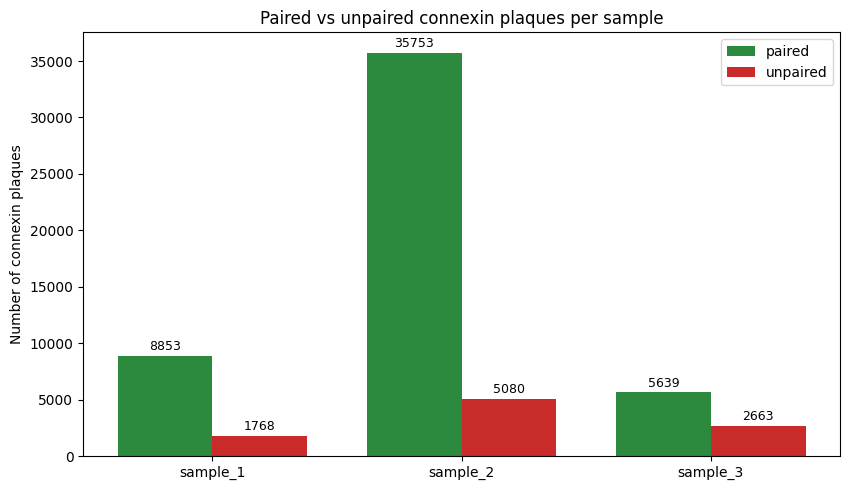

,paired,unpaired,total
sample,,,
sample_1,8853,1768,10621
sample_2,35753,5080,40833
sample_3,5639,2663,8302


In [3]:
# a plaque is 'paired' when it was assigned to a nucleus pair (nucleus_1 not NaN)
paired, unpaired = [], []
for s in samples:
    m = data[s]['matched']
    p = int(m['nucleus_1'].notna().sum())
    paired.append(p)
    unpaired.append(len(m) - p)

w = 0.38
fig, ax = plt.subplots(figsize=(2.2 * len(samples) + 2, 5))
b1 = ax.bar(x - w/2, paired,   w, label='paired',   color=PAIR_COLOR)
b2 = ax.bar(x + w/2, unpaired, w, label='unpaired', color=UNPAIR_COLOR)
ax.bar_label(b1, padding=2, fontsize=9)
ax.bar_label(b2, padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(samples)
ax.set_ylabel('Number of connexin plaques')
ax.set_title('Paired vs unpaired connexin plaques per sample')
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'connexins_paired_vs_unpaired.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({'sample': samples, 'paired': paired, 'unpaired': unpaired,
              'total': np.array(paired) + np.array(unpaired)}).set_index('sample')

## 2. Paired vs unpaired edges

Every Delaunay edge is a candidate cell-cell junction. An edge counts as **paired** if at
least one connexin plaque was assigned to it, and **unpaired** otherwise.

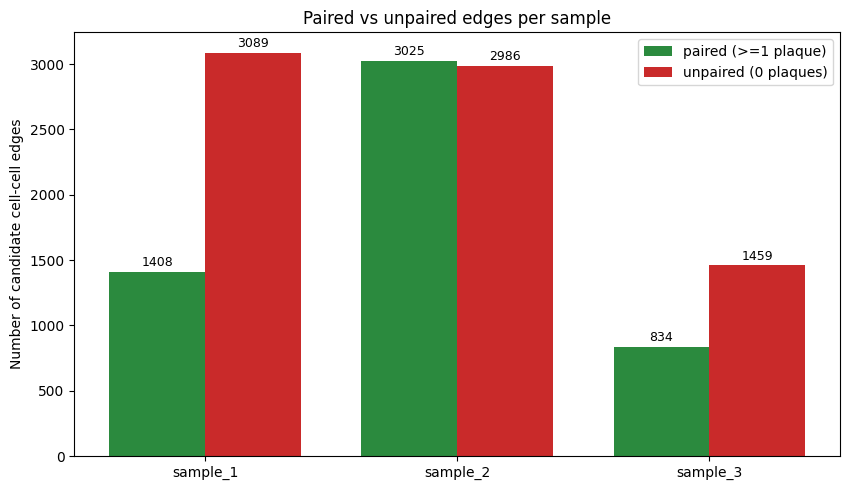

,paired_edges,unpaired_edges
sample,,
sample_1,1408,3089
sample_2,3025,2986
sample_3,834,1459


In [4]:
paired_e, unpaired_e = [], []
for s in samples:
    e = data[s]['edges']
    if e is None:
        paired_e.append(np.nan); unpaired_e.append(np.nan)
        continue
    m = data[s]['matched'].dropna(subset=['nucleus_1'])
    assigned = set(zip(m['nucleus_1'].astype(int), m['nucleus_2'].astype(int)))
    edge_pairs = set(zip(e['nucleus_1'].astype(int), e['nucleus_2'].astype(int)))
    p = len(assigned & edge_pairs)
    paired_e.append(p)
    unpaired_e.append(len(e) - p)

fig, ax = plt.subplots(figsize=(2.2 * len(samples) + 2, 5))
b1 = ax.bar(x - w/2, paired_e,   w, label='paired (>=1 plaque)',  color=PAIR_COLOR)
b2 = ax.bar(x + w/2, unpaired_e, w, label='unpaired (0 plaques)', color=UNPAIR_COLOR)
ax.bar_label(b1, padding=2, fontsize=9)
ax.bar_label(b2, padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(samples)
ax.set_ylabel('Number of candidate cell-cell edges')
ax.set_title('Paired vs unpaired edges per sample')
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'edges_paired_vs_unpaired.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({'sample': samples, 'paired_edges': paired_e,
              'unpaired_edges': unpaired_e}).set_index('sample')

## 3. Plaques detected across depth

Plaque count per depth bin, one curve per sample. Depth is measured from the top of each
sample's segmented volume (`z` centroid x z-spacing), so the samples are compared by relative
depth rather than a shared absolute z.

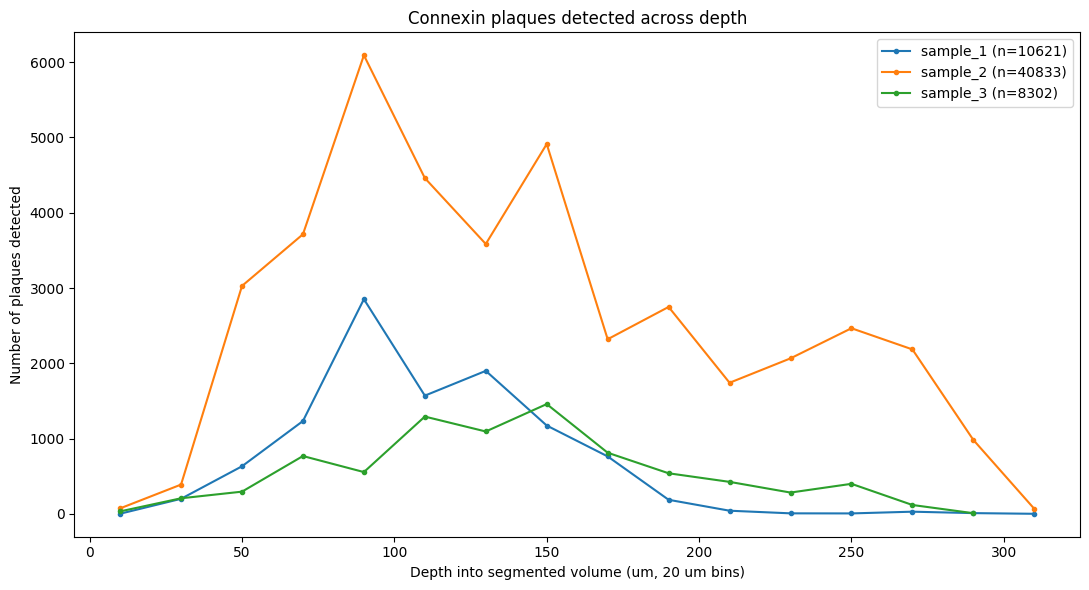

,sample_1,sample_2,sample_3
10.0,3,74,34
30.0,201,390,208
50.0,633,3028,296
70.0,1234,3714,769
90.0,2852,6091,556
110.0,1571,4460,1293
130.0,1900,3585,1095
150.0,1174,4912,1459
170.0,764,2320,813
190.0,188,2749,540


In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
depth_tables = {}
for s in samples:
    z = data[s]['regions']['z'].to_numpy()
    depth_um = z * SPACING_Z
    bin_edges = np.arange(0, depth_um.max() + DEPTH_BIN_UM, DEPTH_BIN_UM)
    counts, _ = np.histogram(depth_um, bins=bin_edges)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(centers, counts, marker='o', ms=3, label=f'{s} (n={len(z)})')
    depth_tables[s] = pd.Series(counts, index=np.round(centers, 1))

ax.set_xlabel(f'Depth into segmented volume (um, {DEPTH_BIN_UM:.0f} um bins)')
ax.set_ylabel('Number of plaques detected')
ax.set_title('Connexin plaques detected across depth')
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plaques_across_depth.png', dpi=150, bbox_inches='tight')
plt.show()

# tabular view (plaques per depth bin, columns = samples)
pd.DataFrame(depth_tables).fillna(0).astype(int)

## 4. Paired plaques across depth

Same as section 3, but restricted to the **paired** connexin plaques (assigned to a nucleus pair)
of each sample — so it shows at which depths the assigned plaques sit.

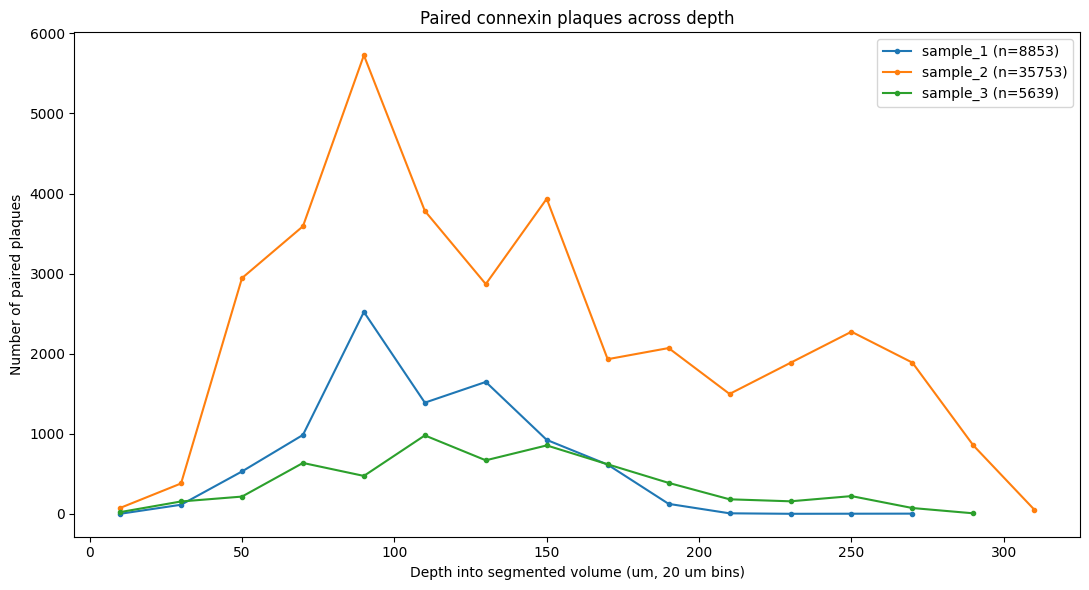

,sample_1,sample_2,sample_3
10.0,0,73,21
30.0,113,379,154
50.0,529,2944,215
70.0,985,3591,635
90.0,2521,5727,473
110.0,1388,3783,979
130.0,1647,2869,668
150.0,923,3935,854
170.0,614,1931,618
190.0,124,2070,386


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
paired_depth_tables = {}
for s in samples:
    m = data[s]['matched']
    z = m.loc[m['nucleus_1'].notna(), 'z'].to_numpy()      # paired plaques only
    if z.size == 0:
        print(f"{s}: no paired plaques")
        continue
    depth_um = z * SPACING_Z
    bin_edges = np.arange(0, depth_um.max() + DEPTH_BIN_UM, DEPTH_BIN_UM)
    counts, _ = np.histogram(depth_um, bins=bin_edges)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(centers, counts, marker='o', ms=3, label=f'{s} (n={len(z)})')
    paired_depth_tables[s] = pd.Series(counts, index=np.round(centers, 1))

ax.set_xlabel(f'Depth into segmented volume (um, {DEPTH_BIN_UM:.0f} um bins)')
ax.set_ylabel('Number of paired plaques')
ax.set_title('Paired connexin plaques across depth')
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'paired_plaques_across_depth.png', dpi=150, bbox_inches='tight')
plt.show()

# tabular view (paired plaques per depth bin, columns = samples)
pd.DataFrame(paired_depth_tables).fillna(0).astype(int)